#Exemple Regression linéaire


##Création de la base de données


In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn .datasets import make_regression
from sklearn.model_selection import train_test_split

In [31]:
X,Y=make_regression(n_samples=100,n_features=3,noise=10)


In [32]:
X.shape, Y.shape

((100, 3), (100,))

In [33]:
Y=Y.reshape(-1,1) #Y.reshape(100,1) Y.reshape(Y.reshape[0],1)
Y.shape

(100, 1)

<ipython-input-34-6c1ca06b059d>:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


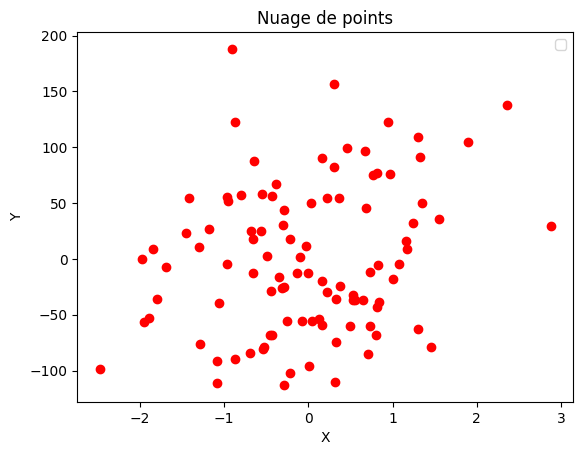

In [34]:
plt.scatter(X[:,0],Y,c='red')
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

##Répartition de la BD

In [35]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=40,shuffle=True)

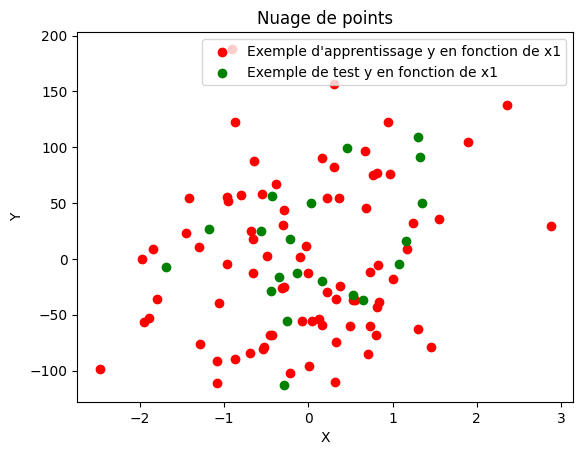

In [36]:
plt.scatter(X_train[:,0],Y_train,c='red',label="Exemple d'apprentissage y en fonction de x1")
plt.scatter(X_test[:,0],Y_test,c='green',label="Exemple de test y en fonction de x1")
plt.legend()
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

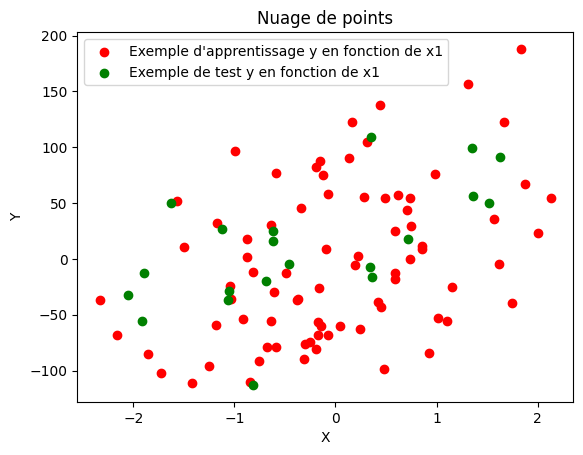

In [37]:
plt.scatter(X_train[:,1],Y_train,c='red',label="Exemple d'apprentissage y en fonction de x1")
plt.scatter(X_test[:,1],Y_test,c='green',label="Exemple de test y en fonction de x1")
plt.legend()
plt.title("Nuage de points")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [21]:
def transformation_variables_explicatives(X):
  vect_un=np.ones((len(X),1))
  return np.hstack((X,vect_un))

In [22]:
def model_lineaire_scalaire(X,Beta):
  return X*Beta[0]+Beta[1]  #X.dot(beta)

In [23]:
def model_lineaire_matricielle(X,Beta):
  X=transformation_variables_explicatives(X)
  return X.dot(Beta)  #X.dot(beta)

In [24]:
def fonction_Cout_Notation_Scalaire(Y,X,Beta):
  return np.sum((Y-model_lineaire_scalaire(X,Beta))**2)/len(Y)

In [25]:
def fonction_Cout_Notation_Matricielle(Y,X,Beta):
  X=transformation_variables_explicatives(X)
  term1=X @ Beta-Y
  n=len(Y)
  return 1/n*term1.T@term1

#Méthode des moindres carrés pour estimer les paramètres du modèle(Vecteur Beta)

In [26]:
def moindres_carres_matricielle(X,Y):
  X=transformation_variables_explicatives(X)
  Beta_estimer=np.linalg.inv(X.T@X)@X.T@Y
  return Beta_estimer

In [27]:
Beta_estimer=moindres_carres_matricielle(X_train,Y_train)
Beta_estimer

array([[72.66620178],
       [10.90228056],
       [80.2460186 ],
       [-0.60586852]])

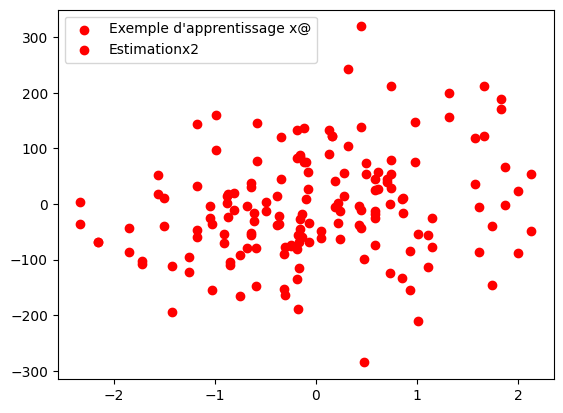

In [45]:
y_pred=model_lineaire_matricielle(X_train,Beta_estimer)
plt.scatter(X_train[:,1],Y_train,c='red',label="Exemple d'apprentissage x@")
plt.scatter(X_train[:,1],y_pred,c='red',label="Estimationx2")
#plt.scatter(X_test,Y_test,c='blue',label="Exemple de test")
#plt.plot(points,y_pred,c='green',label="Modèle linéaire")
plt.legend()
plt.show()

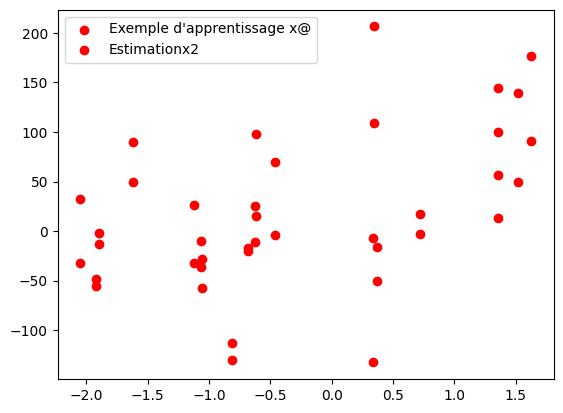

In [44]:
y_pred=model_lineaire_matricielle(X_test,Beta_estimer)
plt.scatter(X_test[:,1],Y_test,c='red',label="Exemple d'apprentissage x@")
plt.scatter(X_test[:,1],y_pred,c='red',label="Estimationx2")
#plt.scatter(X_test,Y_test,c='blue',label="Exemple de test")
#plt.plot(points,y_pred,c='green',label="Modèle linéaire")
plt.legend()
plt.show()

Regression linéaire avec l'api SKlearn

In [ ]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
model.coef_,model.intercept_

(array([[52.92721084]]), array([-0.31349312]))

# Implementation de la méthode de descente de gradient

In [49]:
def gradient(X,Beta,Y):
  n=len(X)
  X=transformation_variables_explicatives(X)
  return (2/n)*X.T@(X@Beta-Y)


def descentGradient(X,Beta,Y,alpha=0.01,n_iteration=2000):
  for i in range(n_iteration):
    Beta=Beta-alpha*gradient(X,Beta,Y)

  return Beta


def history_descentGradient(X,Beta,Y,alpha=0.01,n_iteration=2000):
  errors=[]
  for i in range(n_iteration):
    Beta=Beta-alpha*gradient(X,Beta,Y)
    err=fonction_Cout_Notation_Matricielle(Y,X,Beta)[0][0]
    print(err)
    errors.append(err)
  return Beta,errors

In [54]:
Beta=np.random.randn(X.shape[1]+1,1)
beta_estimer_DG,erreurs=history_descentGradient(X_train,Beta,Y_train,alpha=0.1,n_iteration=300)
print(beta_estimer_DG)

#array([[72.66620178], [10.90228056],  [80.2460186 ], [-0.60586852]])

2917.802851402084
1781.9565812001506
1104.4057136606975
699.0399717895505
455.69461508369363
309.04604144528173
220.28187314628278
166.28799018626773
133.26232352110105
112.93797108144113
100.34597995144486
92.48773074113564
87.54544678083934
84.41157372504568
82.40745992675677
81.1146581227517
80.27339459977793
79.72121063456453
79.3557085514403
79.11181478997645
78.94782251459114
78.83676898234145
78.76107164000908
78.70916648588104
78.67338460813369
78.6485997512549
78.63135961247447
78.6193230312283
78.6108922159402
78.60497038482255
78.60080074553235
78.59785868061567
78.59577902886933
78.59430670485492
78.5932629577554
78.59252218641251
78.59199592735538
78.59162174686027
78.59135550444077
78.59116594569196
78.59103091164403
78.59093467432247
78.59086605962133
78.59081712222539
78.59078220862878
78.59075729360603
78.59073950973472
78.5907268134373
78.59071774770632
78.59071127338518
78.59070664911408
78.59070334585185
78.59070098598498
78.59069929993107
78.59069809519937
78.59069

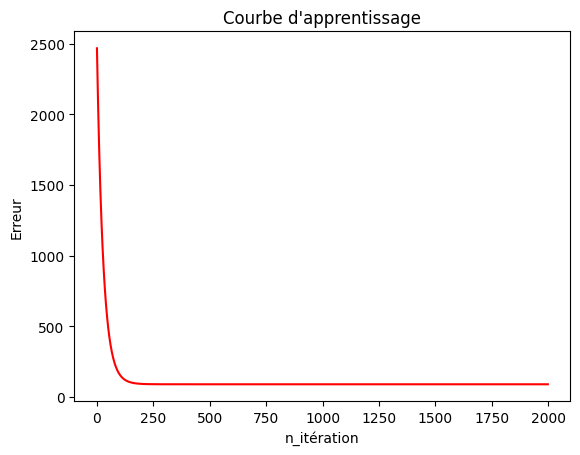

In [ ]:
plt.plot(erreurs,c='r')
plt.xlabel("n_itération")
plt.ylabel("Erreur")
plt.title("Courbe d'apprentissage")
plt.show()


In [ ]:
print(fonction_Cout_Notation_Matricielle(Y_train,X_train,beta_estimer_DG))

[[89.2112925]]


In [ ]:
def coefficient_detemination(y_true,y_pred):
  y_mean=np.mean(y_true)
  sct=np.sum((y_true-y_mean)**2)
  scr=np.sum((y_true-y_pred)**2)
  return 1-(scr/sct)

In [ ]:
y_true=Y_test
y_pred=model_lineaire_matricielle(X_test,beta_estimer_DG)
coefficient_detemination(y_true,y_pred)*100

96.85226862248282